# Выявление закономерностей, определяющие успешность игры

**Цель проекта:** Выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании. Для успешного планирования компании 2017 года должно быть сделано:
- Составление портретов пользователей разных регионов:<br>
 - Определение популярных платформ для каждого региона<br>
 - Определение популярных жанров для каждого региона<br>
 - Определение влияния рейтинга ESRB на продажи для каждого региона<br>
- и проверка гипотез:<br>
 - Средние пользовательские рейтинги платформ Xbox One и PC одинаковые<br>
 - Средние пользовательские рейтинги жанров Action и Sports разные.<br>

**Ход выполнения проекта:** Данные будут взяты из файла: games.csv. В файле предтавлены данные до 2016 года. Качество данных неизвестно, поэтому перед стартом использования данных для составления портретов пользователей и проверки гипотез будет выполнен обзор полученных данных, при необходимости предобработка и исследовательский анализ.

**План выполнения проекта:**
1. Обзор данных
2. Предобработка данных
3. Исследовательский анализ данных (углубленное изучение и визуализация)
4. Составление портрета пользователя для каждого региона
5. Проверка гипотез

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

### Загрузка данных и изучение общей информации

In [2]:
try:
    games_df = pd.read_csv('/datasets/games.csv')
except:
    games_df = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')
    
games_df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Информация о колонках:
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB

#### Вывод

Все данные представлены в одном файле. Всего в файле 16715 записей. Год релиза имеет нецелочисленный тип данных, будет удобнее работать с типоп datetime для этой колонки. Есть пропуски значений в колонках Name, Year_of_Release, Genre (возможно для тех же строк, где нет названия, будет проверено на следующем шаге), Critic_Score, User_Score, Rating.

### Подготовка данных

In [4]:
games = games_df.copy() # копирование всех данных в новый датафрейм для выполнения дальнейших преобразований

#### Приведение названия столбцов к нижнему регистру

In [5]:
games.columns = games.columns.str.lower()
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Проверка дублкатов

In [6]:
games.duplicated().sum()

0

In [7]:
list(games['name'].sort_values().unique())

[' Beyblade Burst',
 ' Fire Emblem Fates',
 " Frozen: Olaf's Quest",
 ' Haikyu!! Cross Team Match!',
 ' Tales of Xillia 2',
 "'98 Koshien",
 '.hack//G.U. Vol.1//Rebirth',
 '.hack//G.U. Vol.2//Reminisce',
 '.hack//G.U. Vol.2//Reminisce (jp sales)',
 '.hack//G.U. Vol.3//Redemption',
 '.hack//Infection Part 1',
 '.hack//Link',
 '.hack//Mutation Part 2',
 '.hack//Outbreak Part 3',
 '.hack//Quarantine Part 4: The Final Chapter',
 '.hack: Sekai no Mukou ni + Versus',
 '007 Racing',
 '007: Quantum of Solace',
 '007: The World is not Enough',
 '007: Tomorrow Never Dies',
 '1 vs. 100',
 '1/2 Summer +',
 '10 Minute Solution',
 '100 All-Time Favorites',
 '100 Classic Books',
 '100 Classic Games',
 '1000 Cooking Recipes from ELLE à table',
 '1001 Touch Games',
 '101-in-1 Explosive Megamix',
 '101-in-1 Party Megamix Wii',
 '101-in-1 Sports Megamix',
 '101-in-1 Sports Party Megamix',
 '1080°: TenEighty Snowboarding',
 '11eyes: CrossOver',
 '12-Sai. Honto no Kimochi',
 '12-Sai. Koisuru Diary',
 '12Ri

In [8]:
list(games['platform'].sort_values().unique())

['2600',
 '3DO',
 '3DS',
 'DC',
 'DS',
 'GB',
 'GBA',
 'GC',
 'GEN',
 'GG',
 'N64',
 'NES',
 'NG',
 'PC',
 'PCFX',
 'PS',
 'PS2',
 'PS3',
 'PS4',
 'PSP',
 'PSV',
 'SAT',
 'SCD',
 'SNES',
 'TG16',
 'WS',
 'Wii',
 'WiiU',
 'X360',
 'XB',
 'XOne']

In [9]:
list(games['genre'].sort_values().unique())

['Action',
 'Adventure',
 'Fighting',
 'Misc',
 'Platform',
 'Puzzle',
 'Racing',
 'Role-Playing',
 'Shooter',
 'Simulation',
 'Sports',
 'Strategy',
 nan]

В данных нет ни явных дубликатов, ни неявных в названиях платформы и жанрах. (т.к. названия игр не критичны для текущего  проекта, обработка названий не требуется, плюс сами названия выглядят уникальными, хоть и есть названия с некоторыми искажениями - пробел в начале названия и названия, начинающиеся с ".hack").

In [10]:
games.loc[:, ['name', 'platform', 'year_of_release']].duplicated().sum()

2

In [11]:
games = games.drop_duplicates(subset=['name', 'platform', 'year_of_release'])
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16712 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16712 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8136 non-null   float64
 9   user_score       10013 non-null  object 
 10  rating           9948 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


In [12]:
games.loc[:, ['name', 'platform', 'year_of_release']].duplicated().sum()

0

При проверке неполных дубликатов по ключевым столбцам было найдено 2 будликата, второй удалён.

#### Удаление строк с пропусками в важных данных

In [13]:
games = games.dropna(subset=['name'])
games.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         6699
rating             6764
dtype: int64

In [14]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16712 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16712 non-null  object 
 1   platform         16712 non-null  object 
 2   year_of_release  16443 non-null  float64
 3   genre            16712 non-null  object 
 4   na_sales         16712 non-null  float64
 5   eu_sales         16712 non-null  float64
 6   jp_sales         16712 non-null  float64
 7   other_sales      16712 non-null  float64
 8   critic_score     8136 non-null   float64
 9   user_score       10013 non-null  object 
 10  rating           9948 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


Были удалены строки, в которых были пропущены название и жанр. Т.к. количество таких строк всего 2, их удаление не критично, зато они не будут мешать при дальнейшем анализе.

#### Заполнение отсутствующих значений колонки year_of_release

In [15]:
games[games['year_of_release'].isna()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN


In [16]:
games['year_of_release'].describe()

count    16443.000000
mean      2006.485921
std          5.875546
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64

Заполнение пропущенных значений года модой платформы:

In [17]:
games['year_of_release'] = (games
                            .groupby('platform')['year_of_release']
                            .transform(lambda x: x.fillna(x.mode().iloc[0] if x.mode().size > 0 else np.nan))
                           )
games['year_of_release'].describe()

count    16712.000000
mean      2006.463978
std          5.905487
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64

Пропущенные значения колонки Год выпуска были заполнены наиболее встречающимися для платформы значениями так, чтобы это не повлияло на общую статистику, при этом можно было бы показывать целочисленное число года (т.к. при наличии пропусков в данных колонка может принимать тип данных float, но не int).

#### Преобразование значения года выпуска в целочисленное

In [18]:
games['year_of_release'] = pd.to_datetime(games['year_of_release'], format='%Y')
games['year_of_release_int'] = games['year_of_release'].dt.year
display(games.head())
games.info()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year_of_release_int
0,Wii Sports,Wii,2006-01-01,Sports,41.36,28.96,3.77,8.45,76.0,8,E,2006
1,Super Mario Bros.,NES,1985-01-01,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,1985
2,Mario Kart Wii,Wii,2008-01-01,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,2008
3,Wii Sports Resort,Wii,2009-01-01,Sports,15.61,10.93,3.28,2.95,80.0,8,E,2009
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,1996


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16712 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 16712 non-null  object        
 1   platform             16712 non-null  object        
 2   year_of_release      16712 non-null  datetime64[ns]
 3   genre                16712 non-null  object        
 4   na_sales             16712 non-null  float64       
 5   eu_sales             16712 non-null  float64       
 6   jp_sales             16712 non-null  float64       
 7   other_sales          16712 non-null  float64       
 8   critic_score         8136 non-null   float64       
 9   user_score           10013 non-null  object        
 10  rating               9948 non-null   object        
 11  year_of_release_int  16712 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 1.7+ MB


#### Обработка пропусков

##### Пропуски в critic_score

In [19]:
games[games['rating'].isna()].head(15)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year_of_release_int
1,Super Mario Bros.,NES,1985-01-01,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,1985
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,1996
5,Tetris,GB,1989-01-01,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,1989
9,Duck Hunt,NES,1984-01-01,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN,1984
10,Nintendogs,DS,2005-01-01,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN,2005
12,Pokemon Gold/Pokemon Silver,GB,1999-01-01,Role-Playing,9.00,6.18,7.20,0.71,NaN,NaN,NaN,1999
18,Super Mario World,SNES,1990-01-01,Platform,12.78,3.75,3.54,0.55,NaN,NaN,NaN,1990
20,Pokemon Diamond/Pokemon Pearl,DS,2006-01-01,Role-Playing,6.38,4.46,6.04,1.36,NaN,NaN,NaN,2006
21,Super Mario Land,GB,1989-01-01,Platform,10.83,2.71,4.18,0.42,NaN,NaN,NaN,1989
22,Super Mario Bros. 3,NES,1988-01-01,Platform,9.54,3.44,3.84,0.46,NaN,NaN,NaN,1988


In [20]:
games['critic_score'].describe()

count    8136.000000
mean       68.965954
std        13.938153
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: critic_score, dtype: float64

Можно заполнить critic_score медианным значением для каждой платформы (расчитать медиану значений по платформам и указать рассчитанное значение вместо пропущенных для каждой платфомы). Но пока оставлю данные как есть, предполагая, что данных будет достаточно для анализа.

##### Пропуски в user_score

In [21]:
games['user_score'].sort_values().unique()

array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '8', '8.1', '8.2',
       '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1', '9.2',
       '9.3', '9.4', '9.5', '9.6', '9.7', 'tbd', nan], dtype=object)

In [22]:
games['user_score'].describe()

count     10013
unique       96
top         tbd
freq       2424
Name: user_score, dtype: object

In [23]:
games['user_score'].value_counts()

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
0.6       2
0.9       2
1.5       2
9.7       1
0         1
Name: user_score, Length: 96, dtype: int64

В user_score есть значения, выставленные в "tbd", в большом количестве. Это значение будет мешать анализу. Возможно они возникло, когда пользователи хотели поставить оценку, но что-то их остановило, и появилось to be describe. Удалю эти значения, чтобы тип данных для колонки был float.

In [24]:
games[games['user_score'] == 'tbd']['name'].count()

2424

In [25]:
games['user_score'] = games['user_score'].replace('tbd', np.nan)
print(f"Количество tbd после замены {games[games['user_score'] == 'tbd']['name'].count()}")
#pd.to_numeric(games['user_score'])
games['user_score'] = games['user_score'].astype(float)
print(type(games['user_score'][0]))
games['user_score'].sort_values().unique()

Количество tbd после замены 0
<class 'numpy.float64'>


array([0. , 0.2, 0.3, 0.5, 0.6, 0.7, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5,
       1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
       2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1,
       4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4,
       5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7,
       6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. ,
       8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. , 9.1, 9.2, 9.3,
       9.4, 9.5, 9.6, 9.7, nan])

Для user_score была выполнена замена строкового значения на численное. Пропуски оставлены как есть с аналогичным critic_score рассуждением.

#### Обработка значений в рейтинге ESRB

In [26]:
games['rating'].value_counts()

E       3989
T       2961
M       1563
E10+    1420
EC         8
RP         3
K-A        3
AO         1
Name: rating, dtype: int64

In [27]:
games[games['rating'].isna()]['genre'].value_counts()

Action          1181
Misc             868
Adventure        857
Sports           839
Role-Playing     721
Fighting         411
Racing           377
Strategy         344
Platform         319
Simulation       305
Shooter          304
Puzzle           238
Name: genre, dtype: int64

Рейтинг K-A больше не используется, по факту это Е. Выпоню замену.<br>
Пустые значения заполню RP - Категория ещё не присвоена.

In [28]:
games['rating'] = games['rating'].replace('K-A', 'E')
games['rating'].value_counts()

E       3992
T       2961
M       1563
E10+    1420
EC         8
RP         3
AO         1
Name: rating, dtype: int64

In [29]:
games['rating'] = games['rating'].fillna('RP')
games['rating'].value_counts()

RP      6767
E       3992
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: rating, dtype: int64

#### Подсчёт суммарных продаж по всем регионам

In [30]:
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year_of_release_int,total_sales
0,Wii Sports,Wii,2006-01-01,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,2006,82.54
1,Super Mario Bros.,NES,1985-01-01,Platform,29.08,3.58,6.81,0.77,NaN,NaN,RP,1985,40.24
2,Mario Kart Wii,Wii,2008-01-01,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,2008,35.52
3,Wii Sports Resort,Wii,2009-01-01,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,2009,32.77
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,RP,1996,31.38


#### Вывод

Для удобства работы с данными при дальнейшем анализе было выполнено:
1. Замена регистра названий колонок на нижний
2. Преобразование типов данных для колонок год выпуска и оценка пользователей
3. Для года выпуска выполнено заполнение пропущенных значений наиболее часто встречаемым для платформы
4. Для оценки пользователей были удалены значения "tbd"
5. Подсчитаны суммарные продажи

In [31]:
# check
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16712 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 16712 non-null  object        
 1   platform             16712 non-null  object        
 2   year_of_release      16712 non-null  datetime64[ns]
 3   genre                16712 non-null  object        
 4   na_sales             16712 non-null  float64       
 5   eu_sales             16712 non-null  float64       
 6   jp_sales             16712 non-null  float64       
 7   other_sales          16712 non-null  float64       
 8   critic_score         8136 non-null   float64       
 9   user_score           7589 non-null   float64       
 10  rating               16712 non-null  object        
 11  year_of_release_int  16712 non-null  int64         
 12  total_sales          16712 non-null  float64       
dtypes: datetime64[ns](1), float64(7

In [32]:
games['rating'].value_counts()

RP      6767
E       3992
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: rating, dtype: int64

### Исследовательский анализ данных

#### Сколько игр выпускалось в разные годы

In [33]:
games['year_of_release_int'].describe()

count    16712.000000
mean      2006.463978
std          5.905487
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release_int, dtype: float64

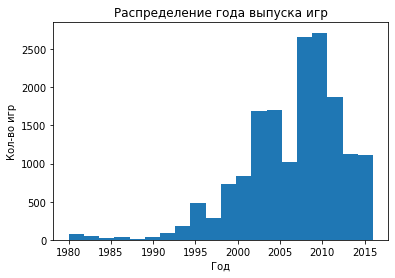

In [34]:
plt.hist(games['year_of_release_int'], bins=20)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
plt.title('Распределение года выпуска игр')
plt.show()

Т.к. игровая индустрия развивается очень стремительно, данные по старым играм можно отбросить. Основная часть данных располагается с 2003 года (25-процентный порог), его и возьму, чтобы отбросить ненужные данные.

#### Как менялись продажи по платформам

In [35]:
pivot_sales_by_platform = (games
                           .groupby(['platform', 'year_of_release_int'])['total_sales']
                           .sum()
                           .reset_index()
                          )
pivot_sales_by_platform

,platform,year_of_release_int,total_sales
0,2600,1980,11.38
1,2600,1981,46.18
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
...,...,...,...
233,XB,2008,0.18
234,XOne,2013,18.96
235,XOne,2014,54.07
236,XOne,2015,60.14


In [36]:
pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS2']

,platform,year_of_release_int,total_sales
130,PS2,2000,39.17
131,PS2,2001,166.43
132,PS2,2002,227.59
133,PS2,2003,184.31
134,PS2,2004,211.81
135,PS2,2005,160.66
136,PS2,2006,103.42
137,PS2,2007,75.99
138,PS2,2008,53.90
139,PS2,2009,26.40


In [37]:
games[(games['platform'] == 'DS') & (games['year_of_release_int'] < 2004)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year_of_release_int,total_sales
15957,Strongest Tokyo University Shogi DS,DS,1985-01-01,Action,0.0,0.0,0.02,0.0,NaN,NaN,RP,1985,0.02


In [38]:
games = games.drop(15957)
games[(games['platform'] == 'DS') & (games['year_of_release_int'] < 2004)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,year_of_release_int,total_sales


In [39]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16711 entries, 0 to 16714
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 16711 non-null  object        
 1   platform             16711 non-null  object        
 2   year_of_release      16711 non-null  datetime64[ns]
 3   genre                16711 non-null  object        
 4   na_sales             16711 non-null  float64       
 5   eu_sales             16711 non-null  float64       
 6   jp_sales             16711 non-null  float64       
 7   other_sales          16711 non-null  float64       
 8   critic_score         8136 non-null   float64       
 9   user_score           7589 non-null   float64       
 10  rating               16711 non-null  object        
 11  year_of_release_int  16711 non-null  int64         
 12  total_sales          16711 non-null  float64       
dtypes: datetime64[ns](1), float64(7

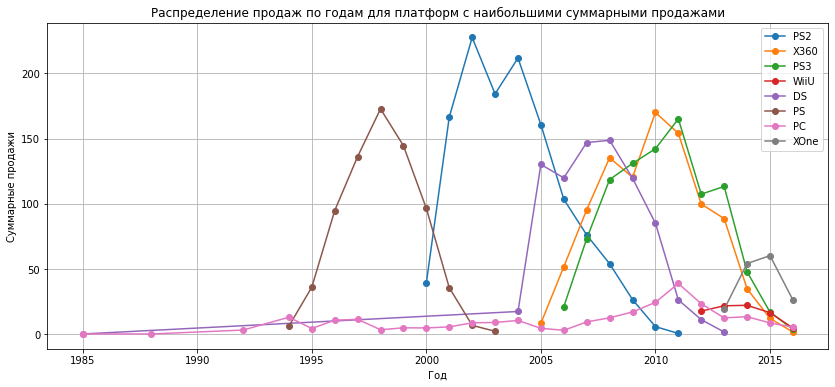

In [40]:
plt.figure(figsize = (14, 6))

plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS2']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS2']['total_sales'],
         marker='o', 
         label='PS2')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'X360']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'X360']['total_sales'],
         marker='o', 
         label='X360')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS3']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS3']['total_sales'],
         marker='o', 
         label='PS3')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'WiiU']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'WiiU']['total_sales'],
         marker='o', 
         label='WiiU')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'DS']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'DS']['total_sales'],
         marker='o', 
         label='DS')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PS']['total_sales'],
         marker='o', 
         label='PS')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PC']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'PC']['total_sales'],
         marker='o', 
         label='PC')
plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'XOne']['year_of_release_int'],
         pivot_sales_by_platform[pivot_sales_by_platform['platform'] == 'XOne']['total_sales'],
         marker='o', 
         label='XOne')

plt.xlabel('Год')
plt.ylabel('Суммарные продажи')
plt.title('Распределение продаж по годам для платформ с наибольшими суммарными продажами')
plt.grid()
plt.legend()

plt.show()

Судя по распределениям в основном наибольшая выручка для платформы приходится на 3-5 год. В среднем платформы существуют около 10 лет. Чтобы делать анализ на актуальных данных, выберу данные за последние 2 года (за 2015 и 2016), т.к. за 2016 год данные не полные и за 2 года данных должно хватить.

#### Выделение данных за последние годы (2015-2016)

In [41]:
games_last_years = games[games['year_of_release_int'] > 2014]
games_last_years.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1109 entries, 31 to 16714
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 1109 non-null   object        
 1   platform             1109 non-null   object        
 2   year_of_release      1109 non-null   datetime64[ns]
 3   genre                1109 non-null   object        
 4   na_sales             1109 non-null   float64       
 5   eu_sales             1109 non-null   float64       
 6   jp_sales             1109 non-null   float64       
 7   other_sales          1109 non-null   float64       
 8   critic_score         458 non-null    float64       
 9   user_score           560 non-null    float64       
 10  rating               1109 non-null   object        
 11  year_of_release_int  1109 non-null   int64         
 12  total_sales          1109 non-null   float64       
dtypes: datetime64[ns](1), float64(7

В выборке за 2 года осталось 1109 записей, но наиболее актуальные

#### Анализ прибыльных платформ

In [42]:
games_last_years.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform
PS4     188.15
XOne     86.29
3DS      42.92
WiiU     20.95
PS3      20.42
PC       13.77
X360     13.48
PSV      10.76
Wii       1.32
PSP       0.12
Name: total_sales, dtype: float64

In [43]:
sales_per_platform_2016 = (games[games['year_of_release_int'] == 2016]
                           .groupby('platform')['total_sales']
                           .sum()
                           .sort_values(ascending=False)
                          )
sales_per_platform_2016

platform
PS4     69.25
XOne    26.15
3DS     15.14
PC       5.25
WiiU     4.60
PSV      4.25
PS3      3.60
X360     1.52
Wii      0.18
Name: total_sales, dtype: float64

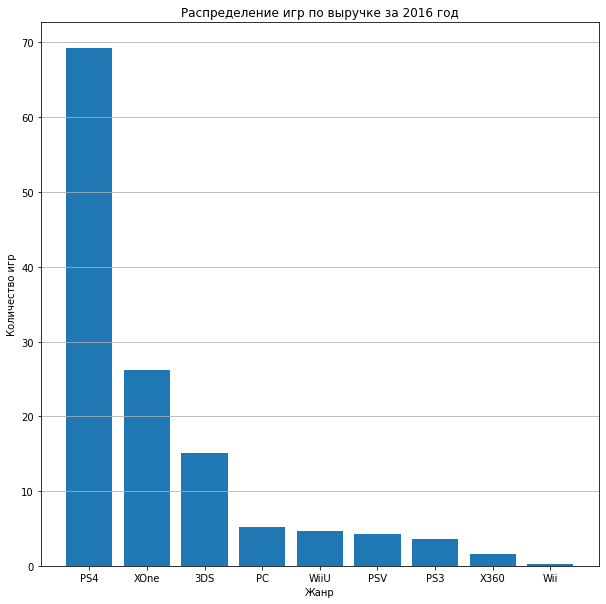

In [44]:
plt.figure(figsize = (10, 10))

#plt.pie(games[games['year_of_release_int'] == 2016].groupby('platform')['total_sales'].sum(),
#        labels=games[games['year_of_release_int'] == 2016].groupby('platform')['total_sales'].sum().index, 
#        autopct='%1.2f%%')
#plt.title('Доля выручки платформ за 2016 год')

plt.bar(sales_per_platform_2016.index, sales_per_platform_2016.values)

plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.title('Распределение игр по выручке за 2016 год')
#plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

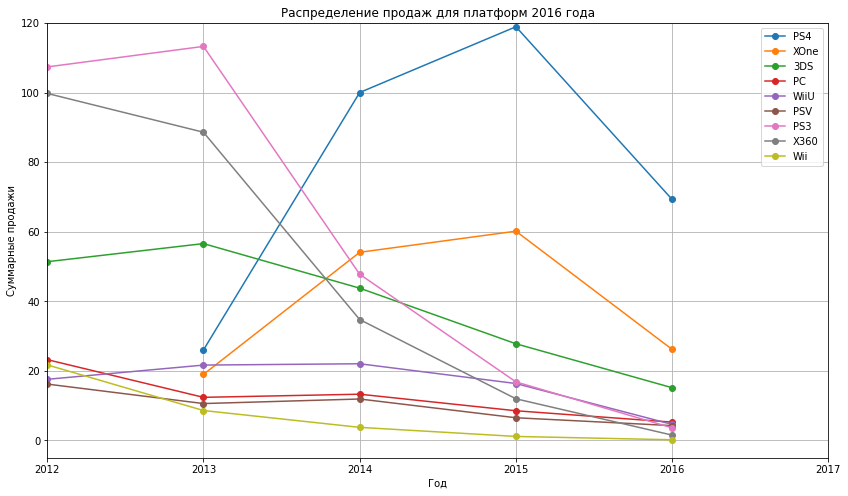

In [45]:
plt.figure(figsize = (14, 8))
plt.xlim(2012, 2017)
plt.ylim(-5, 120)

platforms_2016 = sales_per_platform_2016.index
for platform in platforms_2016:
    plt.plot(pivot_sales_by_platform[pivot_sales_by_platform['platform'] == platform]['year_of_release_int'],
             pivot_sales_by_platform[pivot_sales_by_platform['platform'] == platform]['total_sales'],
             marker='o',
             label=platform)
#    plt.plot(games_last_years[games_last_years['platform'] == platform].groupby('year_of_release_int')['total_sales'].sum(), marker='o', label=platform)

plt.xlabel('Год')
plt.ylabel('Суммарные продажи')
plt.title('Распределение продаж для платформ 2016 года')
plt.grid()
plt.legend()

plt.show()

За последние 2 года (2015-2016) лидируют платформы PS4, XOne и 3DS. По всем платормам наблюдается спад суммарных прожаж в 2016 году, но данные за 2016 год неполные. Рост прибыли с 2013 до 2015 годы наблюдается у PS4 и XOne, остальные платформы имеют спад продаж при сравнении 2014 и 2015 годов. На неполных данных 2016 года лидируют 4 платформы: PS4, XOne, 3DS и PC. Т.к. PC является несменной платформой персональных компьютеров со средней прибылью около 15 млн. копий, её тоже следует оставить в списке прибыльных платформ.

#### График «ящик с усами» по глобальным продажам игр в разбивке по платформам

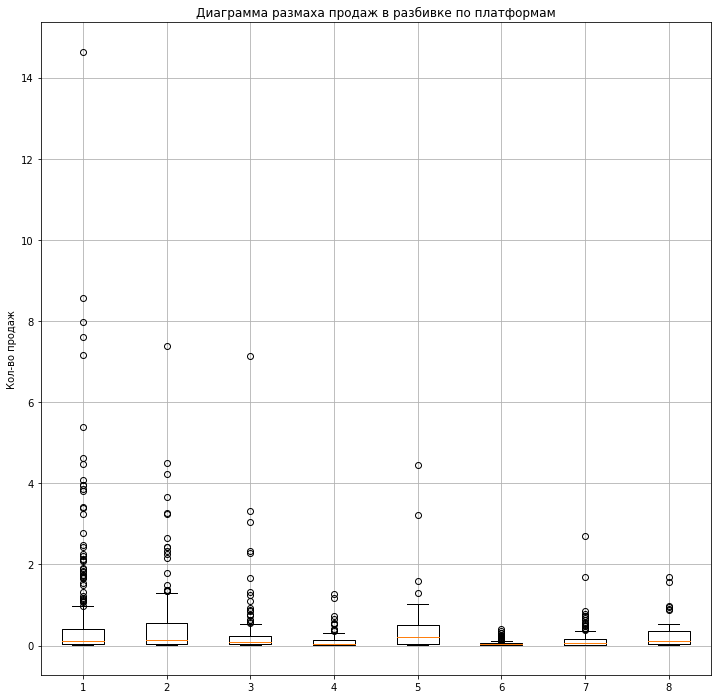

In [46]:
plt.figure(figsize = (12, 12))

#unique_platform = games_last_years['platform'].unique()
#for platform in unique_platform:
#    temp_df = games_last_years[games_last_years['platform'] == platform]
#    temp_df.boxplot('total_sales')
#games_last_years.loc[:, ['platform', 'total_sales']].boxplot()
#plt.boxplot(games_last_years['total_sales'])

plt.boxplot([games_last_years[games_last_years['platform'] == 'PS4']['total_sales'],
             games_last_years[games_last_years['platform'] == 'XOne']['total_sales'],
             games_last_years[games_last_years['platform'] == '3DS']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PC']['total_sales'],
             games_last_years[games_last_years['platform'] == 'WiiU']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PSV']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PS3']['total_sales'],
             games_last_years[games_last_years['platform'] == 'X360']['total_sales']
            ])
plt.ylabel('Кол-во продаж')
plt.title('Диаграмма размаха продаж в разбивке по платформам')
plt.grid()
#plt.ylim(0, 2)

plt.show()

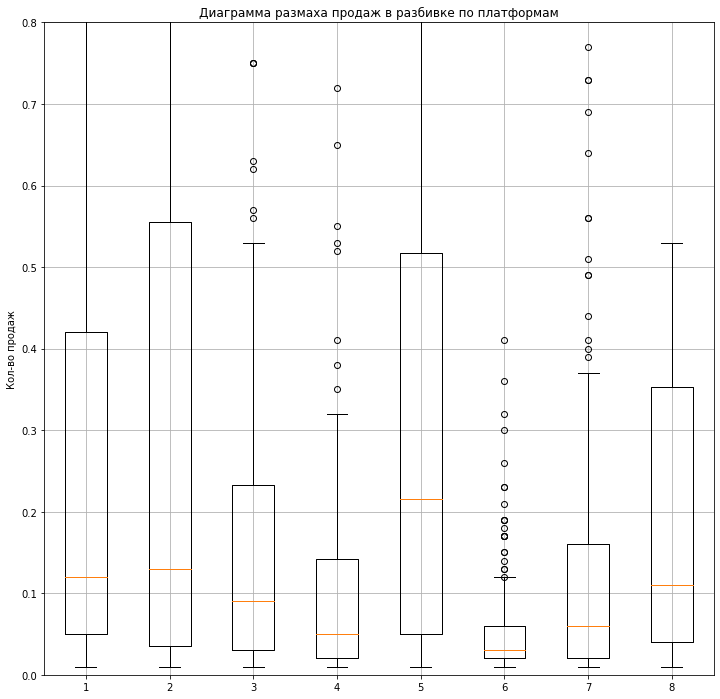

In [47]:
plt.figure(figsize = (12, 12))

plt.boxplot([games_last_years[games_last_years['platform'] == 'PS4']['total_sales'],
             games_last_years[games_last_years['platform'] == 'XOne']['total_sales'],
             games_last_years[games_last_years['platform'] == '3DS']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PC']['total_sales'],
             games_last_years[games_last_years['platform'] == 'WiiU']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PSV']['total_sales'],
             games_last_years[games_last_years['platform'] == 'PS3']['total_sales'],
             games_last_years[games_last_years['platform'] == 'X360']['total_sales']
            ])
plt.ylabel('Кол-во продаж')
plt.title('Диаграмма размаха продаж в разбивке по платформам')
plt.grid()
plt.ylim(0, 0.8)

plt.show()

По данным за последние 2 года медианные значения продаж для платформ колеблятся от 40 тысяч (у платформы PSV) до 220 тысяч копий (у платформы WiiU). Наиболее длинный промежуток от 25% до 75% квартилей, а значит более стабильные продажи, имеет платформа XOne (от 40 тыс. до 550 тыс. копий), чуть меньше промежуток у платформы WiiU (от 50 тыс. до 520 тыс. копий). Наименьший размах у платформы PSV (от 30 до 50 тыс копий).

#### Влияние отзывов на продажи

##### Влияние отзывов критиков на продажи для платформы PS4

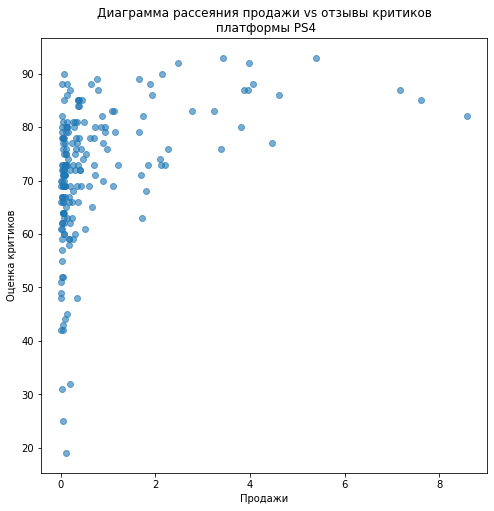

In [48]:
PS4_data = games_last_years[games_last_years['platform'] == 'PS4']

plt.figure(figsize = (8, 8))
plt.scatter(PS4_data['total_sales'], PS4_data['critic_score'], alpha=0.6, marker = 'o')

plt.xlabel('Продажи')
plt.ylabel('Оценка критиков')
plt.title('Диаграмма рассеяния продажи vs отзывы критиков\n платформы PS4')
plt.show()

In [49]:
PS4_data['total_sales'].corr(PS4_data['critic_score'])

0.3928485555130601

Есть зависимость количества продаж от оценки критиков. На графике рассеяния видно небольшое стремление к увеличению колиества продаж при увеличении оценки критика. Коэффициент корреляции = 0,4, что подтверждает наличие небольшой зависимости.

##### Влияние отзывов пользователей на продажи для платформы PS4

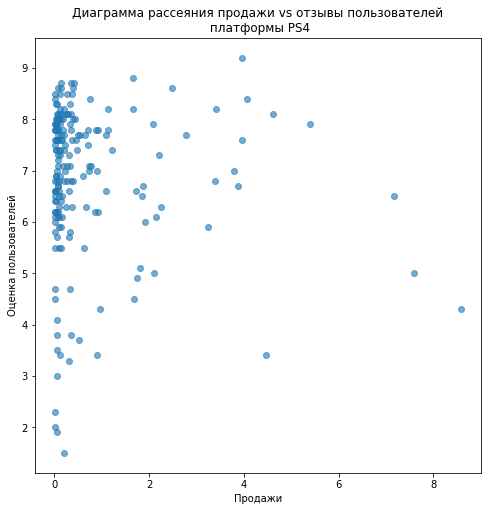

In [50]:
plt.figure(figsize = (8, 8))
plt.scatter(PS4_data['total_sales'], PS4_data['user_score'], alpha=0.6, marker = 'o')

plt.xlabel('Продажи')
plt.ylabel('Оценка пользователей')
plt.title('Диаграмма рассеяния продажи vs отзывы пользователей\n платформы PS4')
plt.show()

In [51]:
PS4_data['total_sales'].corr(PS4_data['user_score'])

-0.05973845712638215

Зависимость количества продаж от оценки пользователей нет. На графике рассеяния не видно зависимости величин. Коэффициент корреляции = -0,03, что показывает отсутствие зависимости.

##### Проверка коэффициента корреляции на других платформах

In [52]:
print("Коэффициент корреляции продажи vs оценка критиков для PC: "
      f"{round(games_last_years[games_last_years['platform'] == 'PC']['total_sales'].corr(games_last_years[games_last_years['platform'] == 'PC']['critic_score']),2)}"
     )
print("Коэффициент корреляции продажи vs оценка критиков для XOne: "
      f"{round(games_last_years[games_last_years['platform'] == 'XOne']['total_sales'].corr(games_last_years[games_last_years['platform'] == 'XOne']['critic_score']),2)}"
     )
print("Коэффициент корреляции продажи vs оценка критиков для 3DS: "
      f"{round(games_last_years[games_last_years['platform'] == '3DS']['total_sales'].corr(games_last_years[games_last_years['platform'] == '3DS']['critic_score']),2)}"
     )

Коэффициент корреляции продажи vs оценка критиков для PC: 0.38
Коэффициент корреляции продажи vs оценка критиков для XOne: 0.43
Коэффициент корреляции продажи vs оценка критиков для 3DS: 0.18


In [53]:
print("Коэффициент корреляции продажи vs оценка пользователей для PC: "
      f"{round(games_last_years[games_last_years['platform'] == 'PC']['total_sales'].corr(games_last_years[games_last_years['platform'] == 'PC']['user_score']),2)}"
     )
print("Коэффициент корреляции продажи vs оценка пользователей для XOne: "
      f"{round(games_last_years[games_last_years['platform'] == 'XOne']['total_sales'].corr(games_last_years[games_last_years['platform'] == 'XOne']['user_score']),2)}"
     )
print("Коэффициент корреляции продажи vs оценка пользователей для 3DS: "
      f"{round(games_last_years[games_last_years['platform'] == '3DS']['total_sales'].corr(games_last_years[games_last_years['platform'] == '3DS']['user_score']),2)}"
     )

Коэффициент корреляции продажи vs оценка пользователей для PC: 0.15
Коэффициент корреляции продажи vs оценка пользователей для XOne: -0.04
Коэффициент корреляции продажи vs оценка пользователей для 3DS: 0.2


Расчёт коэффициента корреляции для других платформ подтверждает выявленую зависимость по первоначально взятой платвофрме PS4.

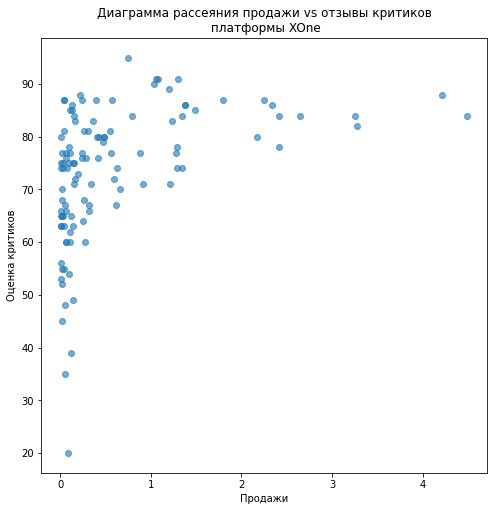

In [54]:
XOne_data = games_last_years[games_last_years['platform'] == 'XOne']

plt.figure(figsize = (8, 8))
plt.scatter(XOne_data['total_sales'], XOne_data['critic_score'], alpha=0.6, marker = 'o')

plt.xlabel('Продажи')
plt.ylabel('Оценка критиков')
plt.title('Диаграмма рассеяния продажи vs отзывы критиков\n платформы XOne')
plt.show()

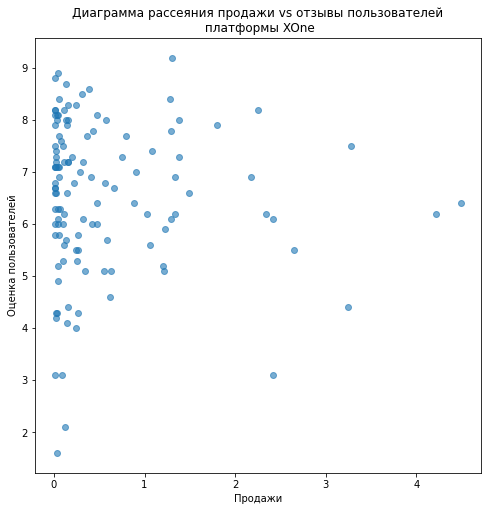

In [55]:
plt.figure(figsize = (8, 8))
plt.scatter(XOne_data['total_sales'], XOne_data['user_score'], alpha=0.6, marker = 'o')

plt.xlabel('Продажи')
plt.ylabel('Оценка пользователей')
plt.title('Диаграмма рассеяния продажи vs отзывы пользователей\n платформы XOne')
plt.show()

Диаграммы рассеяния для платформы XOne аналогичны диаграммам PS4.

#### Распределение игр по жанрам

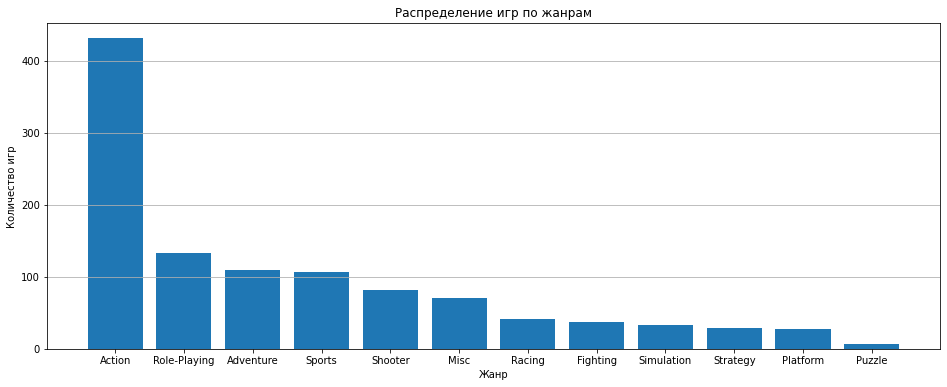

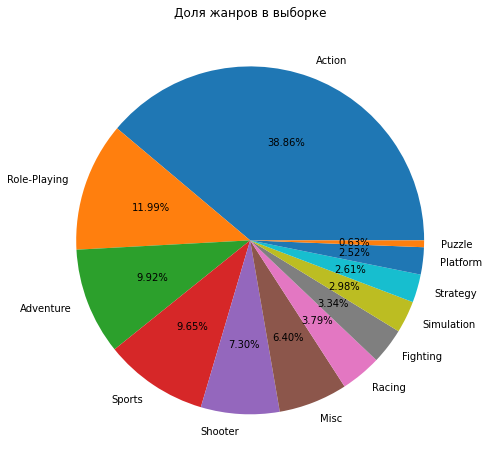

In [56]:
genre_count = games_last_years['genre'].value_counts()

plt.figure(figsize = (16, 6))
plt.bar(genre_count.index, genre_count.values)

plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.title('Распределение игр по жанрам')
#plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

plt.figure(figsize = (8, 8))
plt.pie(genre_count, labels=genre_count.index, autopct='%1.2f%%')
plt.title('Доля жанров в выборке')
plt.show()

In [57]:
games_by_genre = games_last_years.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
games_by_genre

genre
Shooter         105.73
Action          102.13
Sports           64.33
Role-Playing     56.08
Misc             14.17
Fighting         12.37
Adventure        11.98
Racing           10.86
Platform          9.28
Simulation        7.55
Strategy          2.98
Puzzle            0.72
Name: total_sales, dtype: float64

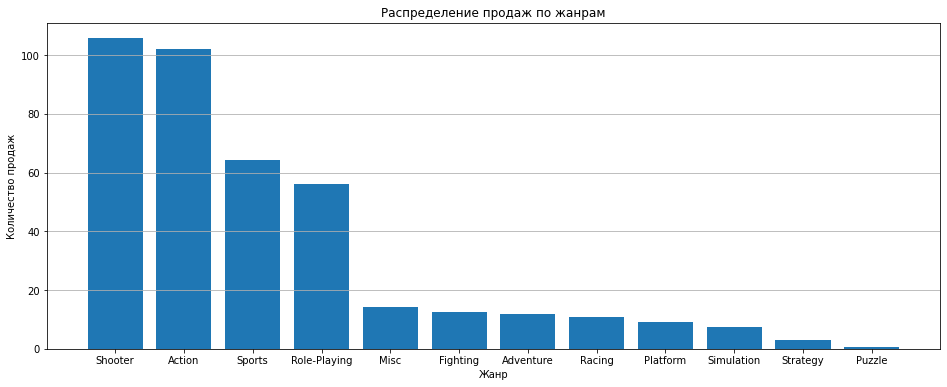

In [58]:
plt.figure(figsize = (16, 6))
plt.bar(games_by_genre.index, games_by_genre.values)

plt.xlabel('Жанр')
plt.ylabel('Количество продаж')
plt.title('Распределение продаж по жанрам')
plt.grid(axis='y')
#plt.xticks(rotation=20)
plt.show()

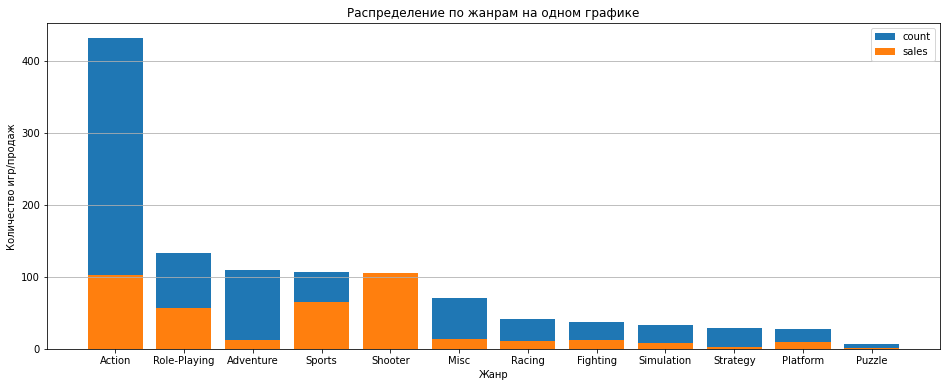

In [59]:
plt.figure(figsize = (16, 6))
plt.bar(genre_count.index, genre_count.values, label='count')
plt.bar(games_by_genre.index, games_by_genre.values, label='sales')
plt.xlabel('Жанр')
plt.ylabel('Количество игр/продаж')
plt.title('Распределение по жанрам на одном графике')
plt.grid(axis='y')
plt.legend()
#plt.xticks(rotation=20)
plt.show()

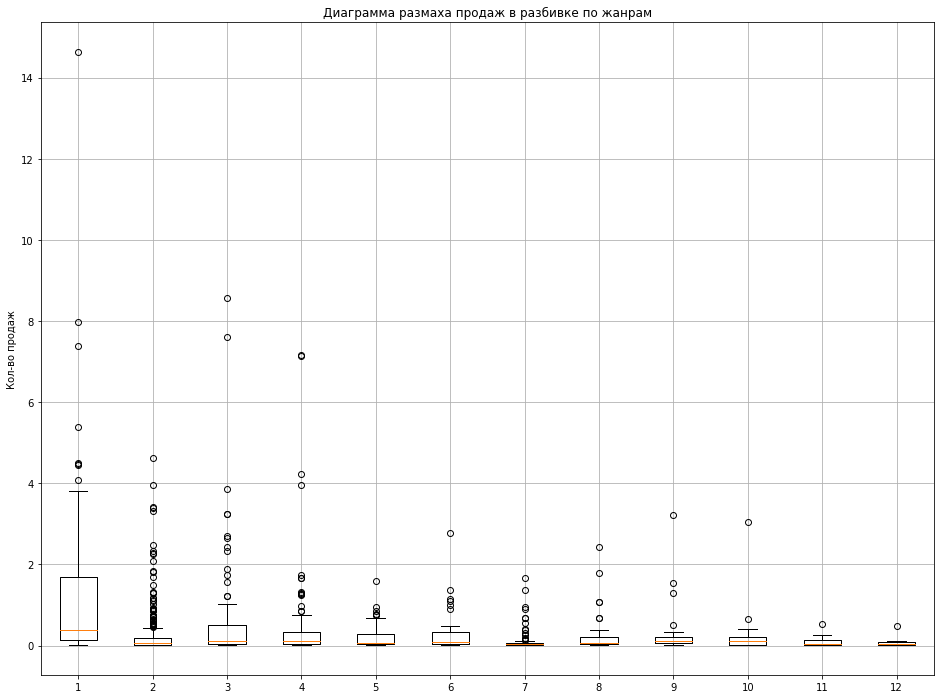

In [60]:
plt.figure(figsize = (16, 12))

plt.boxplot([games_last_years[games_last_years['genre'] == 'Shooter']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Action']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Sports']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Role-Playing']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Misc']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Fighting']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Adventure']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Racing']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Platform']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Simulation']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Strategy']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Puzzle']['total_sales'],
            ])

plt.ylabel('Кол-во продаж')
plt.title('Диаграмма размаха продаж в разбивке по жанрам')
plt.grid()

plt.show()

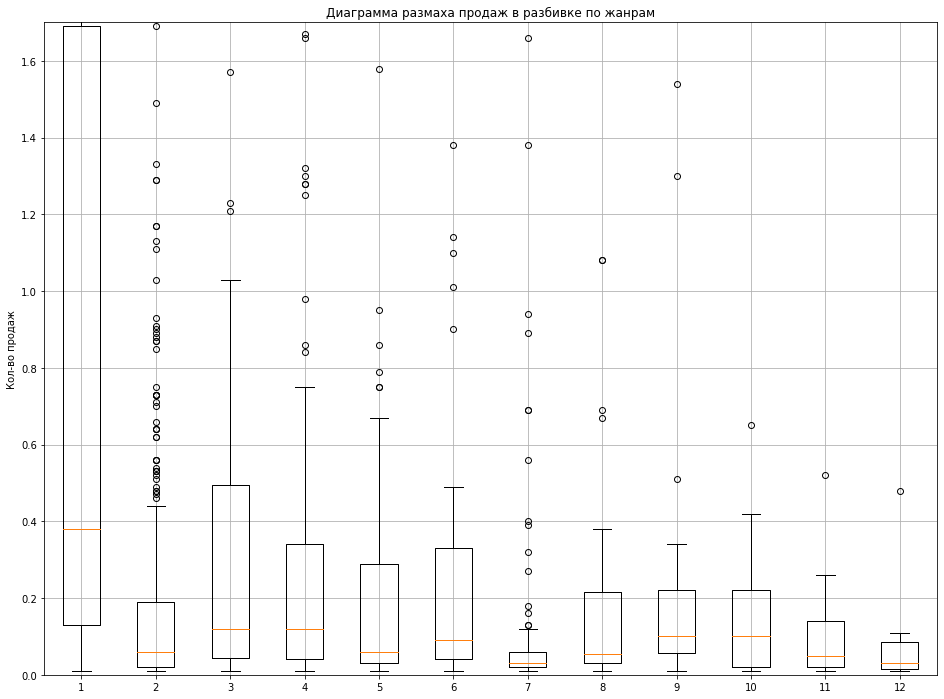

In [61]:
plt.figure(figsize = (16, 12))

plt.boxplot([games_last_years[games_last_years['genre'] == 'Shooter']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Action']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Sports']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Role-Playing']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Misc']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Fighting']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Adventure']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Racing']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Platform']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Simulation']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Strategy']['total_sales'],
             games_last_years[games_last_years['genre'] == 'Puzzle']['total_sales'],
            ])

plt.ylabel('Кол-во продаж')
plt.title('Диаграмма размаха продаж в разбивке по жанрам')
plt.grid()
plt.ylim(0, 1.7)

plt.show()

Наибольшее количество игр в жанре Action. Но распределение по продажам у данного жанра низкое - от ~ 20 до 190 тыс. копий с медианой в 60 тыс. копий.

В продажах за последние 2 года лидирует Shooter. Он имеет стабильные продажи в количестве от ~ 130 тыс. до 1.6 млн. копий с медианным значенийм в 450 тыс. копий, что в несколько раз превышает показатели других жанров.

#### Вывод

1. После просмотра распределения количества выпускаемых игр по годам было принято решение взять данные за последние 2 года
2. Был выполнен анализ изменения продаж по платформам. Для платформ с наибольшими суммарными продажами были построены распределения по годам и сделан вывод, что в среднем платформы существуют около 10 лет
3. Был выполнен анализ платформ-лидеров и выбрано 5 потенциально прибыльних платформ: PS4, XOne, 3DS, WiiU и PC
4. Был построен график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Наиболее стабильными в высоких продажах оказались платформы XOne и WiiU.
5. Была выявлена небольшая зависимость количества продаж от оценки критиков. При увеличении оценки критика присутствует небольшое увеличение колиества продаж. Коэффициент корреляции около 0,4. При это зависимость количества продаж от оценки пользователя не наблюдается.
6. Был выполнен анализ распределения игр по жанрам. Наиболее прибыльным жанром по результатам анализа стал Shooter. Он имеет стабильные продажи в количестве от ~ 130 тыс. до 1.6 млн. копий с медианным значенийм в 450 тыс. копий, что в несколько раз превышает показатели других жанров.

### Составление портрета пользователя каждого региона

#### Самые популярные платформы

In [62]:
def categorize_platform(row):
    if row.name < 5:
        return row['platform']
    return 'Other'

In [63]:
top_na_sales = games_last_years.groupby('platform')['na_sales'].sum().sort_values(ascending=False).reset_index()
top_na_sales['category'] = top_na_sales.apply(categorize_platform, axis=1)
top_na_sales = top_na_sales.groupby('category')['na_sales'].sum().sort_values(ascending=False).reset_index()
top_na_sales

,category,na_sales
0,PS4,63.86
1,XOne,50.30
2,Other,10.52
3,3DS,10.31
4,WiiU,8.86
5,X360,8.05


In [64]:
top_eu_sales = games_last_years.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).reset_index()
top_eu_sales['category'] = top_eu_sales.apply(categorize_platform, axis=1)
top_eu_sales = top_eu_sales.groupby('category')['eu_sales'].sum().sort_values(ascending=False).reset_index()
top_eu_sales

,category,eu_sales
0,PS4,83.54
1,XOne,28.10
2,Other,12.56
3,PC,9.10
4,3DS,7.39
5,PS3,7.30


In [65]:
top_jp_sales = games_last_years.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).reset_index()
top_jp_sales['category'] = top_jp_sales.apply(categorize_platform, axis=1)
top_jp_sales = top_jp_sales.groupby('category')['jp_sales'].sum().sort_values(ascending=False).reset_index()
top_jp_sales

,category,jp_sales
0,3DS,23.55
1,PS4,12.05
2,PSV,8.48
3,PS3,4.97
4,WiiU,4.12
5,Other,0.30


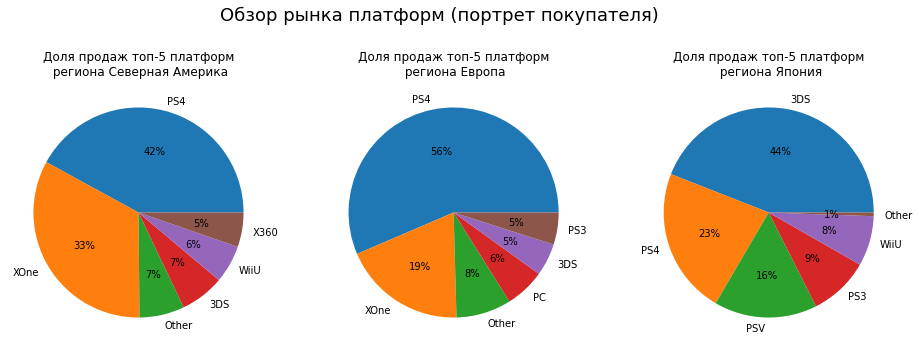

In [66]:
plt.figure(figsize = (16, 6))
plt.suptitle('Обзор рынка платформ (портрет покупателя)', fontsize=18)

plt.subplot(1, 3, 1)
plt.pie(top_na_sales['na_sales'], labels=top_na_sales.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 платформ\n региона Северная Америка')

plt.subplot(1, 3, 2)
plt.pie(top_eu_sales['eu_sales'], labels=top_eu_sales.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 платформ\n региона Европа')

plt.subplot(1, 3, 3)
plt.pie(top_jp_sales['jp_sales'], labels=top_jp_sales.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 платформ\n региона Япония')

plt.show()

Для Северной Америки и Европы наиболее популярной платформой является PS4 (приходится 42% от доли продаж в Северной Америке и 56% в Европе), второй по популярности является XOne (приходится 33% от доли продаж в Северной Америке и 19% в Европе). Для Японии наиболее популярной платформой является 3DS (приходится 44% от доли продаж), второй по популярности является PS4 (приходится 23% от доли продаж).

#### Самые популярные жанры

In [67]:
def categorize_genre(row):
    if row.name < 5:
        return row['genre']
    return 'Other'

In [68]:
top_na_genre = games_last_years.groupby('genre')['na_sales'].sum().sort_values(ascending=False).reset_index()
top_na_genre['category'] = top_na_genre.apply(categorize_genre, axis=1)
top_na_genre = top_na_genre.groupby('category')['na_sales'].sum().sort_values(ascending=False).reset_index()
top_na_genre

,category,na_sales
0,Shooter,48.18
1,Action,33.68
2,Sports,26.31
3,Role-Playing,19.93
4,Other,18.22
5,Misc,5.58


In [69]:
top_eu_genre = games_last_years.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).reset_index()
top_eu_genre['category'] = top_eu_genre.apply(categorize_genre, axis=1)
top_eu_genre = top_eu_genre.groupby('category')['eu_sales'].sum().sort_values(ascending=False).reset_index()
top_eu_genre

,category,eu_sales
0,Shooter,40.28
1,Action,34.82
2,Sports,27.82
3,Other,21.29
4,Role-Playing,17.26
5,Racing,6.52


In [70]:
top_jp_genre = games_last_years.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).reset_index()
top_jp_genre['category'] = top_jp_genre.apply(categorize_genre, axis=1)
top_jp_genre = top_jp_genre.groupby('category')['jp_sales'].sum().sort_values(ascending=False).reset_index()
top_jp_genre

,category,jp_sales
0,Action,23.05
1,Role-Playing,13.48
2,Other,7.74
3,Shooter,3.79
4,Misc,3.19
5,Adventure,2.22


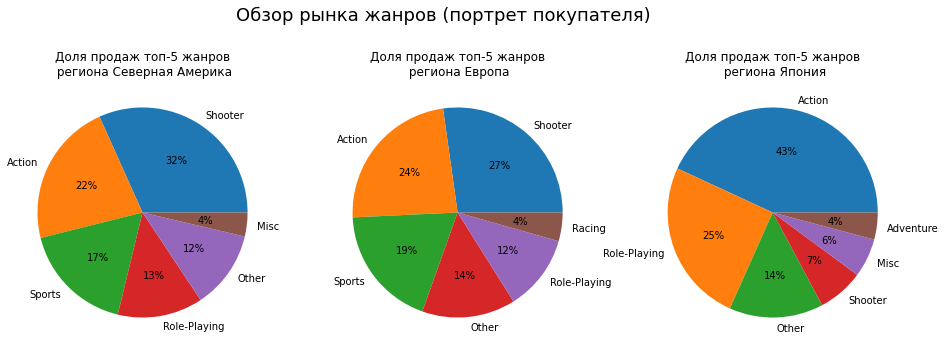

In [71]:
plt.figure(figsize = (16, 6))
plt.suptitle('Обзор рынка жанров (портрет покупателя)', fontsize=18)

plt.subplot(1, 3, 1)
plt.pie(top_na_genre['na_sales'], labels=top_na_genre.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 жанров\n региона Северная Америка')

plt.subplot(1, 3, 2)
plt.pie(top_eu_genre['eu_sales'], labels=top_eu_genre.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 жанров\n региона Европа')

plt.subplot(1, 3, 3)
plt.pie(top_jp_genre['jp_sales'], labels=top_jp_genre.category, autopct='%1.0f%%')
plt.title('Доля продаж топ-5 жанров\n региона Япония')

plt.show()

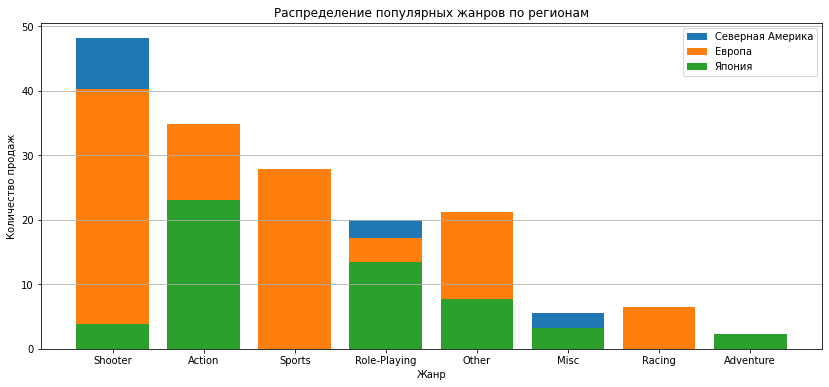

In [72]:
plt.figure(figsize = (14, 6))
plt.bar(top_na_genre.category, top_na_genre.na_sales, label='Северная Америка')
plt.bar(top_eu_genre.category, top_eu_genre.eu_sales, label='Европа')
plt.bar(top_jp_genre.category, top_jp_genre.jp_sales, label='Япония')
plt.xlabel('Жанр')
plt.ylabel('Количество продаж')
plt.title('Распределение популярных жанров по регионам')
plt.grid(axis='y')
plt.legend()
#plt.xticks(rotation=20)
plt.show()

Для Северной Америки и Европы наиболее популярными жанрами являются Shooter и Action, которые занимают половину рынка (Shooter 32% и 27%, Action - 22% и 24%). В Японии - Action (43%) и Role-Playing (25%).

#### Влияние рейтинга ESRB на продажи

In [73]:
na_rating = games_last_years.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
na_rating

rating
M       47.03
RP      37.44
E       26.59
T       22.97
E10+    17.87
Name: na_sales, dtype: float64

In [74]:
eu_rating = games_last_years.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
eu_rating

rating
M       45.54
RP      35.71
E       34.83
T       20.37
E10+    11.54
Name: eu_sales, dtype: float64

In [75]:
jp_rating = games_last_years.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
jp_rating

rating
RP      32.89
T        7.77
E        5.25
M        4.29
E10+     3.27
Name: jp_sales, dtype: float64

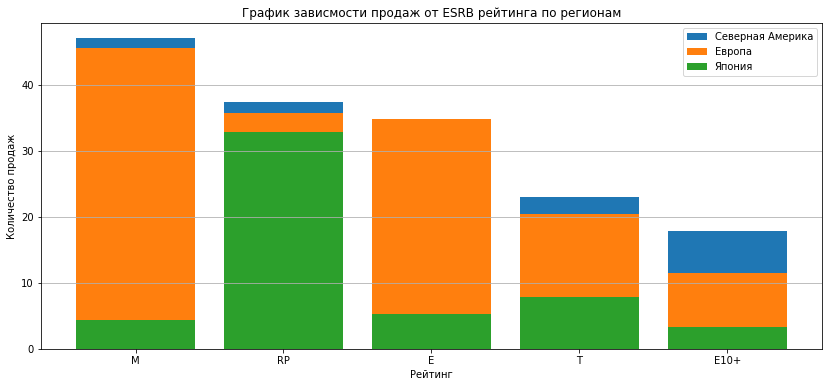

In [76]:
plt.figure(figsize = (14, 6))
plt.bar(na_rating.index, na_rating.values, label='Северная Америка')
plt.bar(eu_rating.index, eu_rating.values, label='Европа')
plt.bar(jp_rating.index, jp_rating.values, label='Япония')
plt.xlabel('Рейтинг')
plt.ylabel('Количество продаж')
plt.title('График зависмости продаж от ESRB рейтинга по регионам')
plt.grid(axis='y')
plt.legend()
plt.show()

Пояснение рейтингов:<br>
M — «Для лиц старше 17 лет»<br>
RP — «Категория ещё не присвоена» (в данную категорию так же были определены игры без рейтинга)<br>
E — «Для всех»<br>
T — «Для лиц старше 13 лет»<br>
E 10+ — «Для лиц старше 10 лет»<br>

Градация по рейтингу ESRB практически одинаковая для Северной Америки и Европы. Для них лидирует категория "M" (для лиц старше 17 лет). Для Японии число продаж игр с рейтингом "M" (для лиц старше 17 лет) в 2 раза ниже, чем с рейтингом "T" (для лиц старше 13 лет), в отличии от Америки и Европы, где соотношение обратное. Вероятно есть зависимость продаж от рейтинга ESRB, но разная, в зависимости от региона.

#### Вывод

Было определено для пользователя каждого региона (NA, EU, JP):
1. Самые популярные платформы (топ-5). График представлен в 4.1. Для Северной Америки и Европы наиболее популярной платформой является PS4, второй по популярности является XOne. Для Японии наиболее популярной платформой является 3DS, второй по популярности является PS4.
2. Самые популярные жанры (топ-5). График представлен в 4.2. Для Северной Америки и Европы наиболее популярными жанрами являются Shooter и Action. В Японии - Action (43%) и Role-Playing (25%).
3. Выявлено влияние рейтинга ESRB на продажи по регионам. Для Северной Америки и Европы наиболее популярными являются игры с рейтингом M — «Для лиц старше 17 лет». В Японии самые популярные игры не имеют рейтинга ESRB, т.е. выбор игры от данного рейтинга не зависит.

### Проверка гипотез

#### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Формулировка гипотез:<br>
*Гипотеза 0* - Средний пользовательский рейтинг платформы Xbox One равен среднему пользовательскому рейтингу платформы PC<br>
*Гипотеза 1* - Средний пользовательский рейтинг платформы Xbox One НЕ равен среднему пользовательскому рейтингу платформы PC

In [77]:
xone_games = games_last_years[games_last_years['platform'] == 'XOne']
pc_games = games_last_years[games_last_years['platform'] == 'PC']

# уровень статистической значимости
alpha = 0.05

# выполнение ttest для двух выборок, в качестве альтернативной используется двусторонняя гипотеза
results = st.ttest_ind(xone_games['user_score'], pc_games['user_score'], nan_policy='omit')

print(f'p-value: {results.pvalue}')

# проверка p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.2778542084733886
Нет оснований отвергнуть нулевую гипотезу


Нулевая гипотеза не была отвергнута в пользу альтернативной. За последние 2 года средний пользовательский рейтинг платформы Xbox One и PC одинаковые.

In [78]:
# Приведены два датасета: сумма покупок, совершённых за месяц посетителями ...

sample_1 = [3071, 3636, 3454, 3151, 2185, 3259, 1727, 2263, 2015,
2582, 4815, 633, 3186, 887, 2028, 3589, 2564, 1422, 1785,
3180, 1770, 2716, 2546, 1848, 4644, 3134, 475, 2686,
1838, 3352]
sample_2 = [1211, 1228, 2157, 3699, 600, 1898, 1688, 1420, 5048, 3007,
509, 3777, 5583, 3949, 121, 1674, 4300, 1338, 3066,
3562, 1010, 2311, 462, 863, 2021, 528, 1849, 255,
1740, 2596]
alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу
results = st.ttest_ind(
sample_1,
sample_2)
print('p-значение:', results.pvalue)
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1912450522572209
Не получилось отвергнуть нулевую гипотезу


#### Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные

Формулировка гипотез:<br>
*Гипотеза 0* - Средний пользовательский рейтинг жанра Action равен среднему пользовательскому рейтингу жанра Sports<br>
*Гипотеза 1* - Средний пользовательский рейтинг жанра Action НЕ равен среднему пользовательскому рейтингу жанра Sports

In [79]:
action_games = games_last_years[games_last_years['genre'] == 'Action']
sports_games = games_last_years[games_last_years['genre'] == 'Sports']

# уровень статистической значимости
alpha = 0.05

# выполнение ttest для двух выборок, в качестве альтернативной используется двусторонняя гипотеза
results = st.ttest_ind(action_games['user_score'], sports_games['user_score'], nan_policy='omit')

print(f'p-value: {results.pvalue}')

# проверка p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.0012846807938657e-13
Отвергаем нулевую гипотезу


Нулевая гипотеза была отвергнута в пользу альтернативной. Средние пользовательские рейтинги жанров Action и Sports разные.

#### Вывод

Была выполнена проверка 2 гипотез:
1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
> Гипотеза не была отвергнута, за последние несколько лет средние пользовательские рейтинги платформ Xbox One и PC одинаковые
2. Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные
> Гипотеза не была отвергнута, средние пользовательские рейтинги жанров Action и Sports разные

### Общий вывод

В ходе работы над проектом было выполнено:

1. Обзор данных
2. Предобработка данных (изменение названий колонок, типов данных столбцов, обработка неверно заполненных значений, заполнение пропцсков, расчёт суммарных продаж)
3. Исследовательский анализ данных (углубленное изучение и визуализация предоставленных данных с определение выборки для анализа)
- Было определено 5 наиболее прибыльные платформ: PS4, XOne, 3DS, WiiU и PC
- Наиболее прибыльным жанром по результатам анализа стал Shooter. Он имеет стабильные продажи в количестве от ~ 130 тыс. до 1.6 млн. копий с медианным значенийм в 450 тыс. копий, что в несколько раз превышает показатели других жанров.
4. Составление портрета пользователя для каждого региона с представлением данных в виде графиков
- Самые популярные платформы. Для Северной Америки и Европы наиболее популярной платформой является PS4 (приходится 42% от доли продаж в Северной Америке и 56% в Европе), второй по популярности является XOne (приходится 33% от доли продаж в Северной Америке и 19% в Европе). Для Японии наиболее популярной платформой является 3DS (приходится 44% от доли продаж), второй по популярности является PS4 (приходится 23% от доли продаж).
- Самые популярные жанры. Для Северной Америки и Европы наиболее популярными жанрами являются Shooter и Action, которые занимают половину рынка (Shooter 32% и 27%, Action - 22% и 24%). В Японии - Action (43%) и Role-Playing (25%).
- Влияние рейтинга ESRB. Для Северной Америки и Европы наиболее популярными являются игры с рейтингом M — «Для лиц старше 17 лет». В Японии самые популярные игры не имеют рейтинга ESRB, т.е. выбор игры от данного рейтинга не зависит.
5. Проверка гипотез. Не были отвергнуты обе гипотезы. 
- За последние несколько лет средние пользовательские рейтинги платформ Xbox One и PC одинаковые
- Средние пользовательские рейтинги жанров Action и Sports разные

**Рекомендации:** потенциально прибыльными и популярными для 2017 года являются платформы PS4, XOne, 3DS и жанр Shooter